In [35]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_excel(r"H:\Meth_Pr\data\Sleep_Work_Productivity_Surve2026-04-24_13_03_21.xlsx")
# clean age column

df['Enter your age ?']= df['Enter your age ?'].fillna(df['Enter your age ?'].median())

# rename the columns

df.rename(columns={
    'How would you rate your overall work productivity?': 'work_productivity',
    'How much do you think your sleep affects your productivity at work?': 'sleep_productivity_effect',
    'What factors do you believe impact your sleep quality? (Select all that apply)': 'sleep_factors',
    'How many breaks do you take during your workday when you are tired ?': 'break_nums',
    'How would you describe your energy levels throughout the workday?': 'energy_levels_per_workday',
    'What is your primary work environment?': 'primary_work_environment',
    'what is you gender ?': 'gender',
    'On a typical work night, how many hours of sleep do you get?': 'sleep_hours',
    
    'I wake up feeling refreshed and ready for work.':
        'wake_up_refreshed',

    'I have difficulty falling asleep the night before an important workday.':
        'difficulty_falling_asleep',

    'Enter your age ?':
        'age',

    'I wake up multiple times during the night and struggle to go back to sleep.':
        'wake_up_multiple_times',

    'On weekends or days off, my sleep schedule is very different from my workday schedule (e.g., sleeping in more than 2 hours later).':
        'weekend_sleep_schedule_difference',

    'I use electronic devices (phone, laptop, TV) in bed within 30 minutes of trying to sleep.':
        'device_use_before_sleep',

    'I find it hard to concentrate on work tasks for more than 15–20 minutes at a time.':
        'difficulty_concentrating',

    'I make careless mistakes (e.g., typos, miscalculations, forgetting steps) that I would not have made if better rested.':
        'careless_mistakes',

    'I often have to re-read emails, documents, or instructions because I lost focus.':
        'reread_due_to_focus_loss',

    'Learning a new software, process, or skill at work feels unusually difficult for me.':
        'difficulty_learning_new_skills',

    'I struggle to generate new ideas or creative solutions to problems.':
        'difficulty_generating_ideas',

    'I forget important tasks, deadlines, or details from meetings.':
        'forget_tasks_deadlines',

    'I feel irritable or short-tempered with colleagues or clients.':
        'irritable_with_colleagues',

    'Small setbacks or minor criticism feel overwhelming or upsetting.':
        'small_setbacks_overwhelming',

    'I avoid collaboration or group work because I feel mentally exhausted.':
        'avoid_collaboration',

    'I have difficulty controlling my emotions during stressful work situations (e.g., tight deadlines, difficult customers).':
        'difficulty_controlling_emotions',

    'I feel physically tired, sluggish, or heavy-eyed during work, even without heavy physical exertion.':
        'physically_tired_at_work',

    'In my job, I have had a close call, minor accident, or injury that I attribute to being too tired. If your job is sedentary, answer based on accidents like tripping, bumping into things, or spilling hot liquids.':
        'accident_due_to_tiredness',

    'Compared to when I am well-rested, I estimate my current work output is...':
        'current_work_output',

    'In the past month, how many work days did you feel you were “present but not productive” (getting less than half of your normal output) due to poor sleep?':
        'unproductive_workdays_due_to_sleep'

}, inplace=True)


df = df.replace(r'\n', ', ', regex=True)
df["sleep_factors"] = df["sleep_factors"].str.split(", ")

# index

df['sleep_quality_and_hygiene_index_(SQLI)']=(df['wake_up_refreshed']+df['difficulty_falling_asleep']+df['wake_up_multiple_times']+df['weekend_sleep_schedule_difference']+df['device_use_before_sleep'])*100/25
df['Cognitive_at_task_perforamnce_index_(CTPI)']=(((df['difficulty_concentrating']+df['careless_mistakes']+df['reread_due_to_focus_loss']+df['difficulty_learning_new_skills']+df['difficulty_generating_ideas']+df['forget_tasks_deadlines'])*100/30).round(2))
df['Emotional_and_social_impact_index(ESII)']=((df['irritable_with_colleagues']+df['small_setbacks_overwhelming']+df['avoid_collaboration']+df['difficulty_controlling_emotions'])*100/20)
df['Physical_and_safety_risk_index(PSRI)']=((df['physically_tired_at_work']+df['accident_due_to_tiredness'])*100/10)
df['Presentative_index(PI)']=(((df['unproductive_workdays_due_to_sleep'])*100/50).round(2))
df['Overall_sleep_Productivity_Impact_index(SPI)']=((df['Cognitive_at_task_perforamnce_index_(CTPI)']+df['Emotional_and_social_impact_index(ESII)']+df['Physical_and_safety_risk_index(PSRI)']+df['Presentative_index(PI)'])*0.3)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 35 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Submission Date                               127 non-null    object 
 1   work_productivity                             127 non-null    object 
 2   sleep_productivity_effect                     127 non-null    object 
 3   sleep_factors                                 127 non-null    object 
 4   break_nums                                    122 non-null    object 
 5   energy_levels_per_workday                     127 non-null    object 
 6   primary_work_environment                      125 non-null    object 
 7   gender                                        127 non-null    object 
 8   sleep_hours                                   127 non-null    object 
 9   wake_up_refreshed                             127 non-null    int

In [37]:
df.head()

,Submission Date,work_productivity,sleep_productivity_effect,sleep_factors,break_nums,energy_levels_per_workday,primary_work_environment,gender,sleep_hours,wake_up_refreshed,...,physically_tired_at_work,accident_due_to_tiredness,current_work_output,unproductive_workdays_due_to_sleep,sleep_quality_and_hygiene_index_(SQLI),Cognitive_at_task_perforamnce_index_(CTPI),Emotional_and_social_impact_index(ESII),Physical_and_safety_risk_index(PSRI),Presentative_index(PI),Overall_sleep_Productivity_Impact_index(SPI)
0,"Apr 24, 2026",High,Moderately,"[Stress, Screen time before bed]",3-4,High,Hybrid,Male,5–6 hrs,2,...,3,1,20–40% less,10,64.0,60.00,70.0,40.0,20.0,57.000
1,"Apr 24, 2026",Moderate,Moderately,[Screen time before bed],3-4,Moderate,Hybrid,Female,6–7 hrs,3,...,3,3,60–80% less,13,60.0,60.00,60.0,60.0,26.0,61.800
2,"Apr 24, 2026",Very high,Extremely,"[Stress, Exercise]",1-2,High,Office,Female,More than 8 hrs,5,...,3,2,60–80% less,7,64.0,60.00,35.0,50.0,14.0,47.700
3,"Apr 24, 2026",High,Extremely,"[Stress, Screen time before bed]",3-4,Moderate,Hybrid,Female,6–7 hrs,2,...,3,3,20–40% less,20,88.0,60.00,40.0,60.0,40.0,60.000
4,"Apr 24, 2026",Moderate,Extremely,"[Stress, Exercise, Screen time before bed, Roo...",1-2,Moderate,Remote,Male,7–8 hrs,3,...,3,3,80–100% less,23,84.0,73.33,50.0,60.0,46.0,68.799


gender
Female               79
Male                 47
Prefer not to say     1
Name: count, dtype: int64
T-statistic: -3.730594563311923
P-value: 0.00028942292568157974


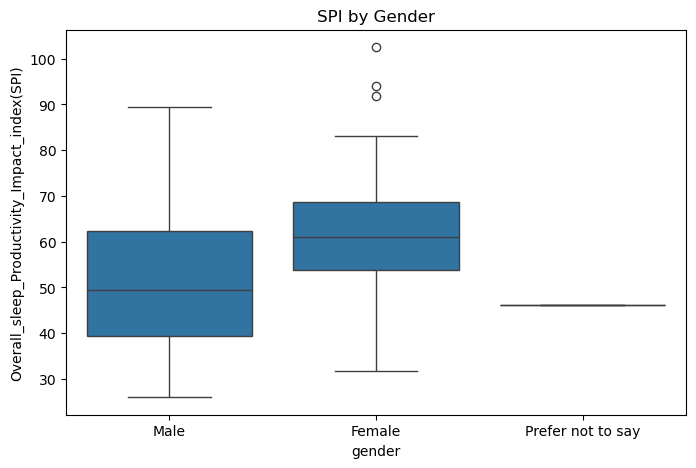

In [38]:
from scipy.stats import ttest_ind

male = df[df['gender'] == 'Male']['Overall_sleep_Productivity_Impact_index(SPI)']
female = df[df['gender'] == 'Female']['Overall_sleep_Productivity_Impact_index(SPI)']

t_stat, p = ttest_ind(male, female)

print(df['gender'].value_counts())
print("T-statistic:", t_stat)
print("P-value:", p)

#-------------------------------------------------------#

plt.figure(figsize=(8,5))

sns.boxplot(
    x='gender',
    y='Overall_sleep_Productivity_Impact_index(SPI)',
    data=df
)

plt.title('SPI by Gender')

plt.show()

In [39]:
from scipy.stats import f_oneway

group1 = df[df['sleep_hours'] == '5–6 hrs']['Overall_sleep_Productivity_Impact_index(SPI)']

group2 = df[df['sleep_hours'] == '6–7 hrs']['Overall_sleep_Productivity_Impact_index(SPI)']

group3 = df[df['sleep_hours'] == '7–8 hrs']['Overall_sleep_Productivity_Impact_index(SPI)']

group4 = df[df['sleep_hours'] == 'More than 8 hrs']['Overall_sleep_Productivity_Impact_index(SPI)']

f_stat, p = f_oneway(group1, group2, group3, group4)

print("F-statistic:", f_stat)
print("P-value:", p)

F-statistic: 0.750889728796027
P-value: 0.5241822262743003


In [40]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['Overall_sleep_Productivity_Impact_index(SPI)'],
    groups=df['sleep_hours'],
    alpha=0.05
)

print(tukey)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------
        5–6 hrs         6–7 hrs   2.8021 0.9324  -6.9885 12.5928  False
        5–6 hrs         7–8 hrs   1.9058 0.9835  -7.9577 11.7693  False
        5–6 hrs Less than 5 hrs  10.7509  0.112  -1.4545 22.9564  False
        5–6 hrs More than 8 hrs   7.2942 0.5981  -6.6549 21.2433  False
        6–7 hrs         7–8 hrs  -0.8963 0.9991  -10.687  8.8944  False
        6–7 hrs Less than 5 hrs   7.9488 0.3714  -4.1979 20.0955  False
        6–7 hrs More than 8 hrs    4.492 0.8983  -9.4057 18.3897  False
        7–8 hrs Less than 5 hrs   8.8451  0.269  -3.3603 21.0505  False
        7–8 hrs More than 8 hrs   5.3884 0.8217  -8.5607 19.3374  False
Less than 5 hrs More than 8 hrs  -3.4567 0.9733 -19.1494  12.236  False
----------------------------------------------------------------

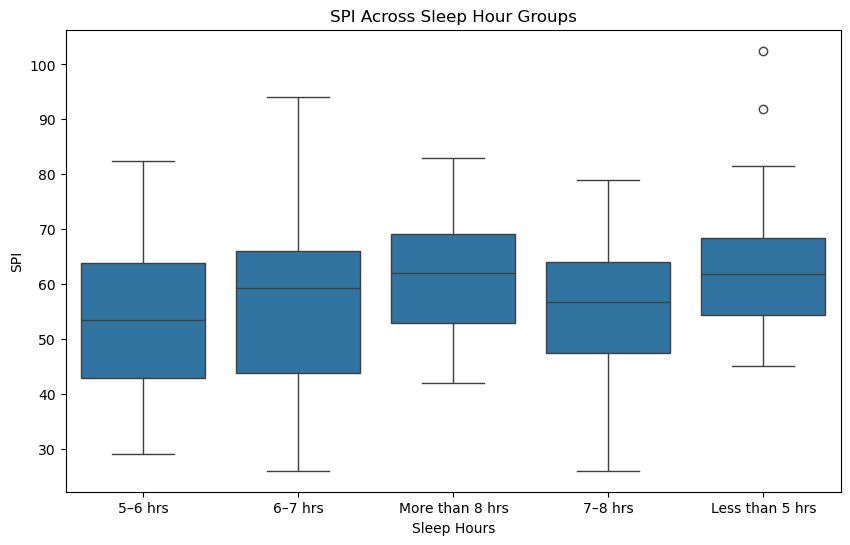

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='sleep_hours',
    y='Overall_sleep_Productivity_Impact_index(SPI)',
    data=df
)

plt.title('SPI Across Sleep Hour Groups')
plt.xlabel('Sleep Hours')
plt.ylabel('SPI')

plt.show()

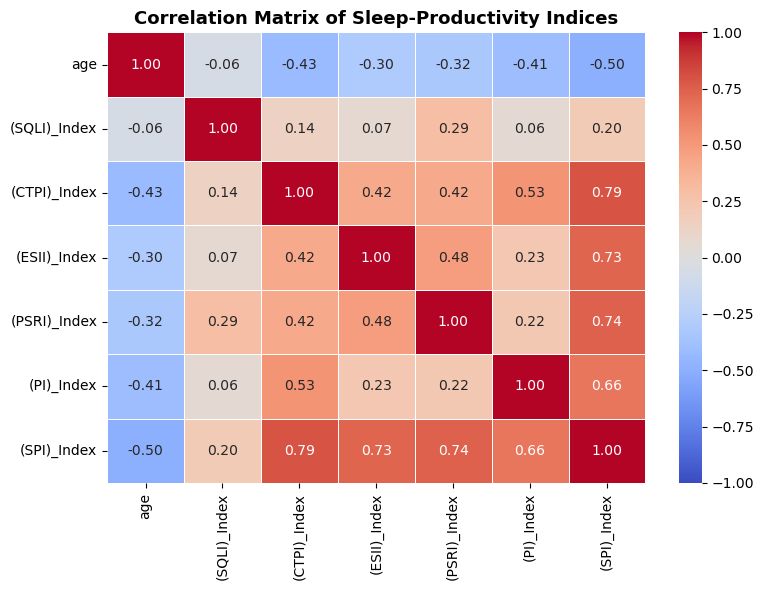

In [42]:
#################### Correlation coefficient ############################

indices = df[['age',
    'sleep_quality_and_hygiene_index_(SQLI)',
    'Cognitive_at_task_perforamnce_index_(CTPI)',
    'Emotional_and_social_impact_index(ESII)',
    'Physical_and_safety_risk_index(PSRI)',
    'Presentative_index(PI)',
    'Overall_sleep_Productivity_Impact_index(SPI)'
]].rename(columns={
    'sleep_quality_and_hygiene_index_(SQLI)': '(SQLI)_Index',
    'Cognitive_at_task_perforamnce_index_(CTPI)': '(CTPI)_Index',
    'Emotional_and_social_impact_index(ESII)': '(ESII)_Index',
    'Physical_and_safety_risk_index(PSRI)': '(PSRI)_Index',
    'Presentative_index(PI)': '(PI)_Index',
    'Overall_sleep_Productivity_Impact_index(SPI)': '(SPI)_Index'
})
corr = indices.corr()

fig, ax= plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
plt.title('Correlation Matrix of Sleep-Productivity Indices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
from scipy import stats
####################### pearson correlation coefficient ##########################
col_1= df['Cognitive_at_task_perforamnce_index_(CTPI)']
col_2= df['Overall_sleep_Productivity_Impact_index(SPI)']
r, p= stats.pearsonr(col_1,col_2)
print(f'pearson r = {r:.4f}')
print(f'P-value = {p:.30f}')

pearson r = 0.7946
P-value = 0.000000000000000000000000000073


In [44]:
from scipy import stats
####################### pearson correlation coefficient ##########################
col_1= df['Emotional_and_social_impact_index(ESII)']
col_2= df['Cognitive_at_task_perforamnce_index_(CTPI)']
r, p= stats.pearsonr(col_1,col_2)
print(f'pearson r = {r:.4f}')
print(f'P-value = {p:.30f}')

pearson r = 0.4156
P-value = 0.000001181287663064732856499557


In [45]:
from scipy import stats
####################### pearson correlation coefficient ##########################
col_1= df['Physical_and_safety_risk_index(PSRI)']
col_2= df['Overall_sleep_Productivity_Impact_index(SPI)']
r, p= stats.pearsonr(col_1,col_2)
print(f'pearson r = {r:.4f}')
print(f'P-value = {p:.30f}')

pearson r = 0.7444
P-value = 0.000000000000000000000011429671


In [46]:
from scipy import stats
####################### pearson correlation coefficient ##########################
col_1= df['sleep_quality_and_hygiene_index_(SQLI)']
col_2= df['Overall_sleep_Productivity_Impact_index(SPI)']
r, p= stats.pearsonr(col_1,col_2)
print(f'pearson r = {r:.4f}')
print(f'P-value = {p:.30f}')

pearson r = 0.1974
P-value = 0.026150779906539908109541769932
